# BRSET Glaucoma — R29 Referable Glaucoma (Bilateral Involvement)

**Goal:** Detect **referable glaucoma** — patients with bilateral increased cup-to-disc ratio
(both eyes affected) who need specialist referral. Uses the same FE 3-way split and
per-encoder MLP pipeline as R28, but with a clinically harder binary target.

| | R28 (any glaucoma) | R29 (referable glaucoma) |
|---|---|---|
| **Positive class** | Any `increased_cup_disc` | Bilateral: ≥ 2 images with `increased_cup_disc=1` |
| **Prevalence** | ~19.7 % (2,024 / 8,524 patients) | ~13.8 % (1,175 / 8,524 patients) |
| **Clinical question** | Does this patient have glaucoma? | Does this patient need a specialist? |
| **Negative class** | No glaucoma | Healthy + unilateral suspects |
| **Pipeline** | PCA-384 → MI → BayesSearch → 25-bag → isotonic → thresh | Same |
| **Split** | FE 3-way (68 / 12 / 20) | Same split |
| **optic_disc masking** | P_MASK = 50 % | Same |

### Label Derivation

```
referable_glaucoma = 1  if  sum(increased_cup_disc) >= 2  across patient images
                     0  otherwise (healthy OR unilateral suspect)
```

**Rationale:** Bilateral structural damage is a strong indicator of true glaucomatous disease,
not physiologic cupping or artifact. Unilateral findings → monitor. Bilateral → refer.

**Data:** Cleaned BRSET (16,266 images, 8,524 patients, ~13.8 % referable+)  
**Source:** `artifacts/brset_eda_fe/` from `feature_engineering/brset_eda_feature_engineering.ipynb`  
**Constraint:** R28 and R27 notebooks are **untouched** — this is a parallel experiment.

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 1 — Imports
# ═══════════════════════════════════════════════════════════════════════
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LogNorm

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import mutual_info_classif

sys.path.insert(0, str(Path.cwd() / 'src'))
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.style.use('seaborn-v0_8-whitegrid')
print('R29 imports OK')

R29 imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 2 — Configuration
# ═══════════════════════════════════════════════════════════════════════

# ─── Task ─────────────────────────────────────────────────────────
DATASET_NAME = 'brset'
TASK         = 'referable_glaucoma'     # derived bilateral label
TASK_SOURCE  = 'increased_cup_disc'     # raw per-image label
RANDOM_SEED  = 42

from multiprocessing import cpu_count
CPU_COUNT = cpu_count()

# ─── Paths ────────────────────────────────────────────────────────
BASE_DIR     = Path.cwd()
FE_DIR       = BASE_DIR / 'artifacts' / 'brset_eda_fe'
EMBED_DIR    = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH  = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'
RESULTS_DIR  = BASE_DIR / 'results' / 'brset_r29_referable_glaucoma'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# R28 baseline for comparison
R28_SUMMARY  = BASE_DIR / 'results' / 'brset_r28_fe_experiment' / 'r28_per_encoder' / 'r28_summary.csv'

# ─── Architecture search space (same as R28) ─────────────────────
ARCHITECTURE_OPTIONS = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
    (128, 64), (384, 192),
    (384, 192, 96),
]

SEARCH_SPACE = {
    'hidden_layer_sizes': Categorical(list(range(len(ARCHITECTURE_OPTIONS)))),
    'alpha': Real(1e-3, 1.0, prior='log-uniform'),
    'learning_rate_init': Real(1e-4, 2e-3, prior='log-uniform'),
    'batch_size': Categorical([64, 128, 256]),
    'pos_class_weight': Real(1.0, 10.0, prior='uniform'),
}

# ─── Pipeline parameters (same as R28) ───────────────────────────
PCA_COMPONENTS       = 384
MI_SELECTION         = True
MI_PERCENTILE_THRESH = 0.15
MI_MIN_COMPONENTS    = 128

BAYES_N_ITER   = 30
BAYES_CV_FOLDS = 3
BAYES_N_JOBS   = min(CPU_COUNT - 1, 6)
MLP_MAX_ITER   = 400
MLP_PATIENCE   = 30

BAG_SEEDS          = [42, 123, 314, 555, 789]
N_BAG_ARCH_VARIANTS = 5
N_BAGS = len(BAG_SEEDS) * N_BAG_ARCH_VARIANTS   # 25

CALIBRATE       = True
DUAL_THRESHOLD  = True
AGG_METHODS     = ['mean', 'max', 'noisy_or', 'mean_top_2', 'mean_top_3', 'trimmed_mean']
THRESHOLD_GRID  = 301
THRESHOLD_FLOOR = 0.05

# ─── Clinical metadata ───────────────────────────────────────────
METADATA_COLS = {
    'age':      'numeric',
    'sex':      'passthrough',
    'diabetes': 'binary_yn',
    'exam_eye': 'binary',
    'camera':   'camera',
}

# ─── optic_disc masking (same as R28) ────────────────────────────
OD_P_MASK_BASE   = 0.50
OD_P_MASK_RANGE  = (0.35, 0.70)
OD_CORRUPT       = 0.10
OD_FEATURE_WEIGHT = 0.50
OD_MISS_WEIGHT    = 0.50
OD_TEST_P_MASK    = 0.25

print(f'FE artifacts:  {FE_DIR}')
print(f'Embeddings:    {EMBED_DIR}')
print(f'Results:       {RESULTS_DIR}')
print(f'Task:          {TASK} (derived from {TASK_SOURCE})')
print(f'PCA: {PCA_COMPONENTS} | MI: drop <{MI_PERCENTILE_THRESH:.0%} | min {MI_MIN_COMPONENTS}')
print(f'BayesSearchCV: {BAYES_N_ITER} iters, {BAYES_CV_FOLDS}-fold, scoring=f1')
print(f'Bagging: {len(BAG_SEEDS)} seeds x {N_BAG_ARCH_VARIANTS} variants = {N_BAGS}')
print(f'OD masking: base={OD_P_MASK_BASE:.0%}, range={OD_P_MASK_RANGE}, corrupt={OD_CORRUPT:.0%}')

FE artifacts:  c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe
Embeddings:    c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings
Results:       c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r29_referable_glaucoma
Task:          referable_glaucoma (derived from increased_cup_disc)
PCA: 384 | MI: drop <15% | min 128
BayesSearchCV: 30 iters, 3-fold, scoring=f1
Bagging: 5 seeds x 5 variants = 25
OD masking: base=50%, range=(0.35, 0.7), corrupt=10%


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 3 — Load Data, Derive Referable Glaucoma Label, FE Artifacts
# ═══════════════════════════════════════════════════════════════════════

# ─── FE engineered features ───────────────────────────────────────
fe_df = pd.read_csv(FE_DIR / 'features_engineered_image_level.csv')
fe_df['patient_id'] = fe_df['patient_id'].astype(str)

# ─── 3-way patient split ──────────────────────────────────────────
splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)

train_pids = set(splits[splits['split'] == 'train']['patient_id'])
val_pids   = set(splits[splits['split'] == 'val']['patient_id'])
test_pids  = set(splits[splits['split'] == 'test']['patient_id'])

assert len(train_pids & val_pids)  == 0, 'Train/val patient leakage!'
assert len(train_pids & test_pids) == 0, 'Train/test patient leakage!'
assert len(val_pids   & test_pids) == 0, 'Val/test patient leakage!'

# ─── Labels for clinical metadata ─────────────────────────────────
labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

# ═══════════════════════════════════════════════════════════════════
# DERIVE REFERABLE GLAUCOMA LABEL (bilateral involvement)
# ═══════════════════════════════════════════════════════════════════
# A patient is referable if they have >= 2 images with increased_cup_disc = 1
# (bilateral = both eyes affected → needs specialist referral)

patient_glaucoma_count = (
    labels_raw.groupby('patient_id')[TASK_SOURCE]
    .sum()
    .rename('glaucoma_image_count')
    .reset_index()
)
patient_glaucoma_count[TASK] = (patient_glaucoma_count['glaucoma_image_count'] >= 2).astype(int)

# Assign referable_glaucoma back to image-level labels
labels_raw = labels_raw.merge(
    patient_glaucoma_count[['patient_id', TASK]],
    on='patient_id', how='left',
)
labels_raw[TASK] = labels_raw[TASK].fillna(0).astype(int)

# Print label derivation summary
n_total  = labels_raw['patient_id'].nunique()
n_any_gl = (patient_glaucoma_count['glaucoma_image_count'] > 0).sum()
n_ref_gl = (patient_glaucoma_count[TASK] == 1).sum()
n_unilat = n_any_gl - n_ref_gl
print(f'Label derivation:')
print(f'  Total patients:       {n_total}')
print(f'  No glaucoma:          {n_total - n_any_gl} ({100*(n_total - n_any_gl)/n_total:.1f}%)')
print(f'  Unilateral (suspect): {n_unilat} ({100*n_unilat/n_total:.1f}%)')
print(f'  Bilateral (REF+):     {n_ref_gl} ({100*n_ref_gl/n_total:.1f}%)')

# ─── Merge FE features with metadata + referable label ────────────
meta_keep = ['image_id', 'age', 'sex', 'diabetes', 'exam_eye', 'camera', 'optic_disc', TASK]
fe_full = fe_df.merge(labels_raw[meta_keep], on='image_id', how='left')

# ─── Feature column names ────────────────────────────────────────
ID_COLS  = {'image_id', 'image_key', 'patient_id', 'split', TASK}
META_SET = set(meta_keep) - {'image_id'}
feat_cols = sorted([c for c in fe_full.columns if c not in ID_COLS and c not in META_SET])

# ─── Split into train / val / test ────────────────────────────────
train_fe = fe_full[fe_full['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
val_fe   = fe_full[fe_full['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
test_fe  = fe_full[fe_full['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

# ─── Embedding files ──────────────────────────────────────────────
embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))

print(f'\nFE features:      {len(feat_cols)} columns')
print(f'Patient split:    {len(train_pids)} train / {len(val_pids)} val / {len(test_pids)} test')
print(f'Image split:      {len(train_fe)} train / {len(val_fe)} val / {len(test_fe)} test')
print(f'REF+ rate:        train={train_fe[TASK].mean():.1%}  val={val_fe[TASK].mean():.1%}  test={test_fe[TASK].mean():.1%}')
print(f'Embedding files:  {len(embedding_files)}')
for f in embedding_files:
    print(f'  {f.name}')

Label derivation:
  Total patients:       8524
  No glaucoma:          6500 (76.3%)
  Unilateral (suspect): 849 (10.0%)
  Bilateral (REF+):     1175 (13.8%)

FE features:      488 columns
Patient split:    5796 train / 1023 val / 1705 test
Image split:      11047 train / 1950 val / 3269 test
REF+ rate:        train=14.3%  val=16.1%  test=14.0%
Embedding files:  7
  Embeddings_brset_convnextv2_base_.csv
  Embeddings_brset_dinov3_convnext_base.csv
  Embeddings_brset_dinov3_vitb16.csv
  Embeddings_brset_RETFound_dinov2_shanghai.csv
  Embeddings_brset_RETFound_mae_natureCFP.csv
  Embeddings_brset_RETFound_mae_shanghai.csv
  Embeddings_brset_vit_base_.csv


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 4 — Helper Functions (identical to R28)
# ═══════════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def find_optimal_threshold(y_true, y_proba, grid_size=301, floor=0.05):
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128,
                       random_state=42):
    mi_scores = mutual_info_classif(
        X_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    X_train_sel = X_train[:, mask]
    X_others_sel = [X[:, mask] for X in X_others]
    return X_train_sel, X_others_sel, mask, mi_scores


class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=0, alpha=0.01,
                 learning_rate_init=0.001, batch_size=64,
                 pos_class_weight=1.0, max_iter=400,
                 early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=30, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None

    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes

    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate='adaptive',
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size, max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
            warm_start=self.warm_start,
        )
        sw = make_sample_weights(y, pos_class_weight=self.pos_class_weight)
        self._mlp.fit(X, y, sample_weight=sw)
        self.classes_ = self._mlp.classes_
        return self

    def predict(self, X): return self._mlp.predict(X)
    def predict_proba(self, X): return self._mlp.predict_proba(X)


def aggregate_patient_proba(pids, proba, method='mean'):
    df = pd.DataFrame({'patient': pids, 'proba': proba})
    if method == 'mean':
        return df.groupby('patient')['proba'].mean()
    elif method == 'max':
        return df.groupby('patient')['proba'].max()
    elif method == 'noisy_or':
        return df.groupby('patient')['proba'].apply(
            lambda x: 1.0 - np.prod(1.0 - x.values.clip(0, 0.9999)))
    elif method == 'mean_top_2':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max())
    elif method == 'mean_top_3':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[-3:].mean() if len(x) >= 3
                      else (np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max()))
    elif method == 'trimmed_mean':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[1:].mean() if len(x) >= 3 else x.mean())
    raise ValueError(f'Unknown method: {method}')


def aggregate_patient_labels(pids, labels):
    df = pd.DataFrame({'patient': pids, 'label': labels})
    return df.groupby('patient')['label'].max()


def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            print(f'    WARNING: metadata col {col!r} not found, skipping')
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


def make_wider(arch, factor=1.5):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_deeper(arch):
    return arch + (max(64, arch[-1] // 2),)

def make_narrower(arch, factor=0.67):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_shallower(arch):
    if len(arch) > 1:
        return arch[:-1]
    return (max(64, arch[0] // 2),)


def _bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2:
        return X_s
    if od_w != 1.0:
        X_s[:, -2] *= od_w
    if miss_w != 1.0:
        X_s[:, -1] *= miss_w
    return X_s


def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    cm_plot = np.ma.masked_where(cm <= 0, cm)
    vmax = int(cm.max()) if cm.size else 1
    norm = LogNorm(vmin=1, vmax=max(1, vmax))
    im = ax.imshow(cm_plot, cmap='viridis', interpolation='nearest', norm=norm)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Count (log)', fontsize=9)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


def plot_roc_curve(fpr, tpr, auc_val, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=Normalize(0, 1))
    lc.set_array(fpr); lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0,1],[0,1],'--', color='#666', lw=1.2, label='Chance')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f'{title}\nAUC = {auc_val:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04).set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


print(f'Helpers OK  ({len(ARCHITECTURE_OPTIONS)} arch options, {len(AGG_METHODS)} agg methods)')

Helpers OK  (11 arch options, 6 agg methods)


---
## Per-Encoder MLP Evaluation — Referable Glaucoma

Same R28 pipeline (PCA-384 → MI → BayesSearchCV → 25-bag → isotonic → dual threshold)
with the **referable glaucoma** target (bilateral `increased_cup_disc`).

**Key difference from R28:** The positive class is now ~13.8 % (vs 19.7 %), so the
class imbalance is slightly worse. The `pos_class_weight` parameter in BayesSearchCV
will adapt to compensate.

Loops over all 7 encoders independently — each gets its own MLP model.

R29 — Per-Encoder MLP (PCA-384 + MI) — Referable Glaucoma (bilateral)

[1/7] convnextv2_base_ — CACHED, loading previous results

[2/7] dinov3_convnext_base — CACHED, loading previous results

[3/7] dinov3_vitb16 — CACHED, loading previous results

[4/7] RETFound_dinov2_shanghai — CACHED, loading previous results

[5/7] RETFound_mae_natureCFP — CACHED, loading previous results

[6/7] R29 — RETFound_mae_shanghai
  PCA: 1024->384 (98.9% var)
  MI: 384->384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 30 iters...
  CV F1=0.4979 | arch=(256,) | lr=0.000123 | w=3.29
  [Bagging] 25 models
  * Best: raw+noisy_or (val F1=0.7778, thresh=0.736)
  P25: F1=0.6424  AUC=0.9348  BalAcc=0.7977
  CV-Test gap: -0.1445 | Val-Test gap: +0.1354
  Time: 3281s
              precision    recall  f1-score   support

           0      0.946     0.940     0.943      1476
           1      0.630     0.655     0.642       229

    accuracy                          0.902      1705
   macro avg      0.788

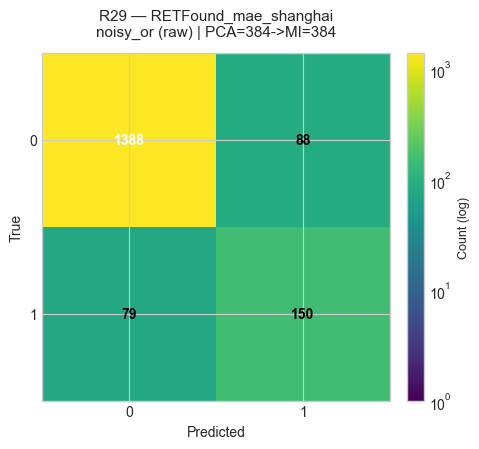

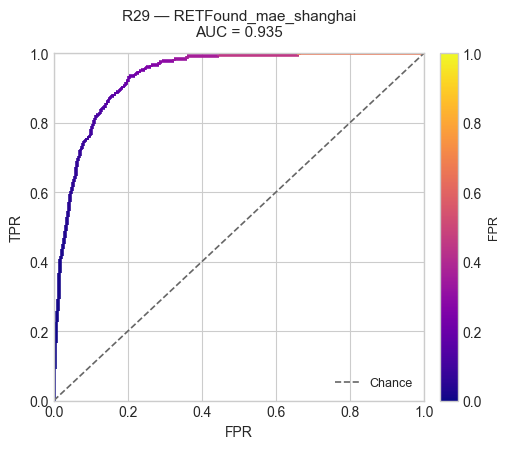


[7/7] R29 — vit_base_
  PCA: 768->384 (98.9% var)
  MI: 384->384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 30 iters...
  CV F1=0.4915 | arch=(512,) | lr=0.002000 | w=3.86
  [Bagging] 25 models
  * Best: calibrated+noisy_or (val F1=0.7493, thresh=0.432)
  P25: F1=0.6618  AUC=0.9379  BalAcc=0.8518
  CV-Test gap: -0.1703 | Val-Test gap: +0.0875
  Time: 1232s
              precision    recall  f1-score   support

           0      0.967     0.904     0.935      1476
           1      0.565     0.799     0.662       229

    accuracy                          0.890      1705
   macro avg      0.766     0.852     0.798      1705
weighted avg      0.913     0.890     0.898      1705



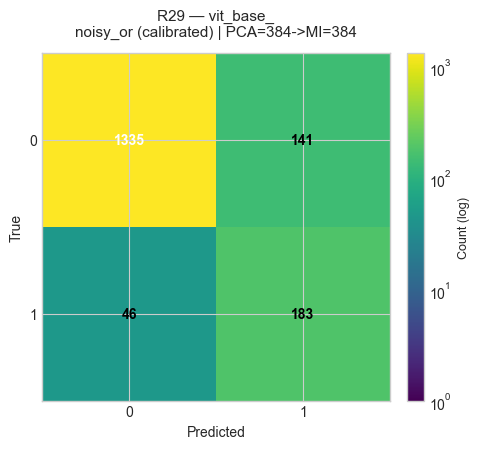

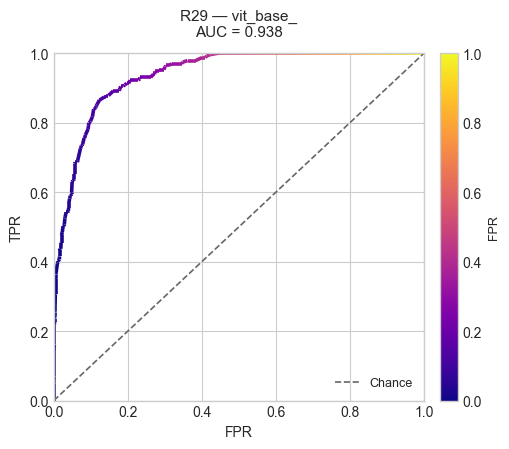


R29 complete! Total: 4515s (75.2 min)

-- R29 Per-Encoder Summary (sorted by P25 F1) --
               embedding    cv_f1   val_f1    f1_P0   f1_P25  f1_P100  auc_P25 best_agg
           dinov3_vitb16 0.538132 0.748428 0.762712 0.721382 0.523457 0.950291     mean
        convnextv2_base_ 0.540066 0.777778 0.739300 0.698413 0.513636 0.951364 noisy_or
    dinov3_convnext_base 0.493115 0.731844 0.718310 0.687161 0.525896 0.947150 noisy_or
               vit_base_ 0.491495 0.749296 0.702703 0.661844 0.491620 0.937919 noisy_or
   RETFound_mae_shanghai 0.497855 0.777778 0.685950 0.642398 0.424691 0.934782 noisy_or
RETFound_dinov2_shanghai 0.503449 0.729097 0.691207 0.642241 0.478261 0.929306 noisy_or
  RETFound_mae_natureCFP 0.501928 0.707775 0.694444 0.633803 0.474820 0.922158 noisy_or


In [5]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 5 — Per-Encoder MLP with FE Split — Referable Glaucoma
# ═══════════════════════════════════════════════════════════════════════

R29_DIR = RESULTS_DIR / 'r29_per_encoder'
R29_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 80)
print('R29 — Per-Encoder MLP (PCA-384 + MI) — Referable Glaucoma (bilateral)')
print('=' * 80)

r29_results = []
t0_b = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint: skip if results already exist ──────────────────
    chk_dir = R29_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED, loading previous results')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        sc_prev = prev['scenarios']
        r29_results.append({
            'embedding': sname,
            'dim_raw': prev.get('emb_dim_raw', 0), 'dim_pca': prev['pca_dim'],
            'dim_mi': prev['mi_selected'], 'pca_var': prev['pca_var'],
            'dim_total': 0,
            'arch': prev['architecture'], 'alpha': prev['alpha'], 'lr': prev['lr'],
            'pos_weight': prev['pos_weight'], 'cv_f1': prev['best_cv_f1'],
            'val_f1': prev['best_val_f1'], 'best_agg': prev['best_agg'],
            'threshold': prev['threshold'], 'proba_type': prev['proba_type'],
            'f1_P0': sc_prev['P0']['f1'], 'f1_P25': sc_prev['P25']['f1'],
            'f1_P100': sc_prev['P100']['f1'],
            'auc_P0': sc_prev['P0']['auc'], 'auc_P25': sc_prev['P25']['auc'],
            'auc_P100': sc_prev['P100']['auc'],
            'bal_acc_P25': sc_prev['P25']['bal_acc'],
            'prec_P25': sc_prev['P25']['precision'], 'rec_P25': sc_prev['P25']['recall'],
            'n_test_patients': sc_prev['P25']['n_patients'],
            'time_s': 0,
        })
        continue

    print(f'\n{"="*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R29 — {sname}')
    print(f'{"="*80}')
    t0 = time.time()

    # ── Load & split ──────────────────────────────────────────────
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    # Merge the referable_glaucoma label
    ref_label = labels_raw[['image_id', TASK]].drop_duplicates(subset='image_id')
    if 'image_name' in df.columns and 'image_id' not in df.columns:
        df['image_id'] = df['image_name'].str.replace(r'\.(jpg|png|jpeg)$', '', regex=True)
    df = df.merge(ref_label, on='image_id', how='left')
    df[TASK] = df[TASK].fillna(0).astype(int)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_b_tr = b_train['patient_id'].to_numpy()
    pids_b_va = b_val['patient_id'].to_numpy()
    pids_b_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}->{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask_b, mi_scores_b = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept_b = mi_mask_b.sum()
        print(f'  MI: {nc}->{n_kept_b}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept_b = nc

    # ── Metadata ──────────────────────────────────────────────────
    X_tr_meta_b, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta_b, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta_b, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim_b = X_tr_meta_b.shape[1]

    # ── OD masking for BayesSearchCV ──────────────────────────────
    rng_hp_b = np.random.default_rng(RANDOM_SEED)
    od_tr_b, miss_tr_b = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp_b, OD_CORRUPT)
    X_tr_full_b = np.hstack([X_tr_sel, X_tr_meta_b, od_tr_b, miss_tr_b])
    ndim_b = X_tr_full_b.shape[1]
    print(f'  Dims: {n_kept_b} PCA + {meta_dim_b} meta + 2 OD = {ndim_b}')

    # ── Scale ─────────────────────────────────────────────────────
    scaler_b = StandardScaler()
    X_tr_s_b = scaler_b.fit_transform(X_tr_full_b)
    X_tr_s_b = _apply_od_weights(X_tr_s_b, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # Pre-compute val/test scenarios
    vt_b = {}
    for sc, pm in [('P0', 0.0), ('P25', OD_TEST_P_MASK), ('P100', 1.0)]:
        rng_vb = np.random.default_rng(RANDOM_SEED + 7000)
        rng_tb = np.random.default_rng(RANDOM_SEED + 9999)
        od_vb, miss_vb = _mask_od(b_val['optic_disc'], pm, rng_vb)
        od_tb, miss_tb = _mask_od(b_test['optic_disc'], pm, rng_tb)
        Xvb = scaler_b.transform(np.hstack([X_va_sel, X_va_meta_b, od_vb, miss_vb]))
        Xtb = scaler_b.transform(np.hstack([X_te_sel, X_te_meta_b, od_tb, miss_tb]))
        vt_b[sc] = (
            _apply_od_weights(Xvb.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT),
            _apply_od_weights(Xtb.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT),
        )

    # ── BayesSearchCV ─────────────────────────────────────────────
    print(f'  [BayesSearchCV] {BAYES_N_ITER} iters...')
    base_b = MLPWrapperForBayesSearch(
        max_iter=MLP_MAX_ITER, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
        random_state=RANDOM_SEED,
    )
    bayes_b = BayesSearchCV(
        estimator=base_b, search_spaces=SEARCH_SPACE,
        n_iter=BAYES_N_ITER, cv=BAYES_CV_FOLDS,
        n_jobs=BAYES_N_JOBS, scoring='f1',
        random_state=RANDOM_SEED, verbose=0,
    )
    bayes_b.fit(X_tr_s_b, yb_train)

    bp_b = bayes_b.best_params_
    bcv_f1 = bayes_b.best_score_
    ai = bp_b.get('hidden_layer_sizes', 0)
    barch = ARCHITECTURE_OPTIONS[ai] if isinstance(ai, int) else ai
    balpha = bp_b['alpha']
    blr    = bp_b['learning_rate_init']
    bbs    = bp_b['batch_size']
    bw     = bp_b['pos_class_weight']
    print(f'  CV F1={bcv_f1:.4f} | arch={barch} | lr={blr:.6f} | w={bw:.2f}')

    # ── Bagging ───────────────────────────────────────────────────
    barchs = [barch, make_wider(barch), make_deeper(barch), make_narrower(barch), make_shallower(barch)]
    print(f'  [Bagging] {N_BAGS} models')

    cal_p = {}
    cal_l = {}
    bvp = {sc: [] for sc in ['P0','P25','P100']}
    btp = {sc: [] for sc in ['P0','P25','P100']}

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_b_tr)
        sss_b = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss_b.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m_b = np.isin(pids_b_tr, list(itr_pids))
        va_m_b = np.isin(pids_b_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(b_train.iloc[np.where(tr_m_b)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler_b.transform(np.hstack([X_tr_sel[tr_m_b], X_tr_meta_b[tr_m_b], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m_b]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(b_train.iloc[np.where(va_m_b)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler_b.transform(np.hstack([X_tr_sel[va_m_b], X_tr_meta_b[va_m_b], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m_b]

        svp = []
        for a_idx, arch_b in enumerate(barchs):
            mlp_b = MLPClassifier(
                hidden_layer_sizes=arch_b, alpha=balpha,
                learning_rate='adaptive',
                learning_rate_init=blr, batch_size=bbs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw_b = make_sample_weights(y_it, bw)
            mlp_b.fit(X_it, y_it, sample_weight=sw_b)

            svp.append(mlp_b.predict_proba(X_iv)[:, 1])

            for sc in ['P0','P25','P100']:
                Xv_sc, Xt_sc = vt_b[sc]
                bvp[sc].append(mlp_b.predict_proba(Xv_sc)[:, 1])
                btp[sc].append(mlp_b.predict_proba(Xt_sc)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp_b = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl_b = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso_b = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso_b.fit(cp_b, cl_b)

    avg_v_b  = {sc: iso_b.predict(np.mean(bvp[sc], axis=0)) for sc in ['P0','P25','P100']}
    avg_t_b  = {sc: iso_b.predict(np.mean(btp[sc], axis=0)) for sc in ['P0','P25','P100']}
    avg_v_bR = {sc: np.mean(bvp[sc], axis=0) for sc in ['P0','P25','P100']}
    avg_t_bR = {sc: np.mean(btp[sc], axis=0) for sc in ['P0','P25','P100']}

    # ── Threshold sweep on FIXED VAL ──────────────────────────────
    plv = aggregate_patient_labels(pids_b_va, yb_val)
    b_agg, b_f1v, b_thr, b_pt = 'mean', 0.0, 0.5, 'calibrated'
    for ptn, vs in [('calibrated', avg_v_b), ('raw', avg_v_bR)]:
        for agg in AGG_METHODS:
            pp = aggregate_patient_proba(pids_b_va, vs['P25'], method=agg)
            com = pp.index.intersection(plv.index)
            t, f = find_optimal_threshold(plv.loc[com].values, pp.loc[com].values,
                                         grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR)
            if f > b_f1v:
                b_f1v, b_agg, b_thr, b_pt = f, agg, t, ptn

    print(f'  * Best: {b_pt}+{b_agg} (val F1={b_f1v:.4f}, thresh={b_thr:.3f})')

    # ── Evaluate on TEST ──────────────────────────────────────────
    plt_b = aggregate_patient_labels(pids_b_te, yb_test)
    b_sc = {}
    for sc in ['P0','P25','P100']:
        tp_b = avg_t_b[sc] if b_pt == 'calibrated' else avg_t_bR[sc]
        pp = aggregate_patient_proba(pids_b_te, tp_b, method=b_agg)
        com = pp.index.intersection(plt_b.index)
        yt = plt_b.loc[com].values
        yp = pp.loc[com].values
        yh = (yp >= b_thr).astype(int)
        b_sc[sc] = {
            'f1': float(f1_score(yt, yh, zero_division=0)),
            'precision': float(precision_score(yt, yh, zero_division=0)),
            'recall': float(recall_score(yt, yh, zero_division=0)),
            'auc': float(roc_auc_score(yt, yp)),
            'bal_acc': float(balanced_accuracy_score(yt, yh)),
            'n_patients': len(com),
        }

    elapsed_b = time.time() - t0
    sb25 = b_sc['P25']
    print(f'  P25: F1={sb25["f1"]:.4f}  AUC={sb25["auc"]:.4f}  BalAcc={sb25["bal_acc"]:.4f}')
    print(f'  CV-Test gap: {bcv_f1 - sb25["f1"]:+.4f} | Val-Test gap: {b_f1v - sb25["f1"]:+.4f}')
    print(f'  Time: {elapsed_b:.0f}s')

    # Save per-embedding
    out_b = R29_DIR / f'{emb_idx:02d}_{sname}'
    out_b.mkdir(parents=True, exist_ok=True)

    tp_main = avg_t_b['P25'] if b_pt == 'calibrated' else avg_t_bR['P25']
    pp_m = aggregate_patient_proba(pids_b_te, tp_main, method=b_agg)
    com_m = pp_m.index.intersection(plt_b.index)
    yt_m = plt_b.loc[com_m].values
    yp_m = pp_m.loc[com_m].values
    yh_m = (yp_m >= b_thr).astype(int)

    cm_b = confusion_matrix(yt_m, yh_m)
    rep_b = classification_report(yt_m, yh_m, digits=3)
    fpr_b, tpr_b, _ = roc_curve(yt_m, yp_m)
    print(rep_b)

    pd.DataFrame(cm_b).to_csv(out_b / 'confusion_matrix.csv', index=False)
    (out_b / 'classification_report.txt').write_text(rep_b, encoding='utf-8')
    pd.DataFrame({'fpr': fpr_b, 'tpr': tpr_b}).to_csv(out_b / 'roc_curve.csv', index=False)
    pd.DataFrame({
        'patient_id': com_m, 'y_true': yt_m, 'y_pred': yh_m, 'y_proba': yp_m,
    }).to_csv(out_b / 'patient_predictions_P25.csv', index=False)

    hp_b = {
        'track': 'R29', 'embedding': sname, 'architecture': str(barch),
        'alpha': float(balpha), 'lr': float(blr), 'batch_size': int(bbs),
        'pos_weight': float(bw), 'best_cv_f1': float(bcv_f1),
        'best_val_f1': float(b_f1v), 'best_agg': b_agg, 'threshold': float(b_thr),
        'proba_type': b_pt, 'pca_dim': nc, 'mi_selected': int(n_kept_b),
        'pca_var': float(var_exp), 'n_bags': N_BAGS,
        'emb_dim_raw': emb_dim_raw, 'ndim': ndim_b,
        'scenarios': b_sc,
    }
    with open(out_b / 'hyperparameters.json', 'w') as f:
        json.dump(hp_b, f, indent=2)

    plot_confusion_matrix(cm_b, title=f'R29 — {sname}\n{b_agg} ({b_pt}) | PCA={nc}->MI={n_kept_b}',
                          save_path=out_b / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr_b, tpr_b, sb25['auc'], title=f'R29 — {sname}',
                  save_path=out_b / 'roc_curve.png', show=True)

    r29_results.append({
        'embedding': sname,
        'dim_raw': emb_dim_raw, 'dim_pca': nc, 'dim_mi': int(n_kept_b),
        'pca_var': float(var_exp), 'dim_total': ndim_b,
        'arch': str(barch), 'alpha': float(balpha), 'lr': float(blr),
        'pos_weight': float(bw), 'cv_f1': float(bcv_f1),
        'val_f1': float(b_f1v), 'best_agg': b_agg, 'threshold': float(b_thr),
        'proba_type': b_pt,
        'f1_P0': b_sc['P0']['f1'], 'f1_P25': b_sc['P25']['f1'], 'f1_P100': b_sc['P100']['f1'],
        'auc_P0': b_sc['P0']['auc'], 'auc_P25': b_sc['P25']['auc'], 'auc_P100': b_sc['P100']['auc'],
        'bal_acc_P25': b_sc['P25']['bal_acc'],
        'prec_P25': b_sc['P25']['precision'], 'rec_P25': b_sc['P25']['recall'],
        'n_test_patients': b_sc['P25']['n_patients'],
        'time_s': float(elapsed_b),
    })

total_b = time.time() - t0_b
print(f'\n{"="*80}')
print(f'R29 complete! Total: {total_b:.0f}s ({total_b/60:.1f} min)')
print(f'{"="*80}')

# Save summary
r29_df = pd.DataFrame(r29_results).sort_values('f1_P25', ascending=False)
r29_df.to_csv(R29_DIR / 'r29_summary.csv', index=False)

print('\n-- R29 Per-Encoder Summary (sorted by P25 F1) --')
show_cols = ['embedding', 'cv_f1', 'val_f1', 'f1_P0', 'f1_P25', 'f1_P100', 'auc_P25', 'best_agg']
print(r29_df[[c for c in show_cols if c in r29_df.columns]].to_string(index=False))

---
## Loss Curves — R29 Referable Glaucoma

Self-contained cell: reloads config, data, and retrains **one MLP per encoder** 
(best hyperparameters from checkpoint) to plot train / val loss curves.

Found 7 encoder checkpoints


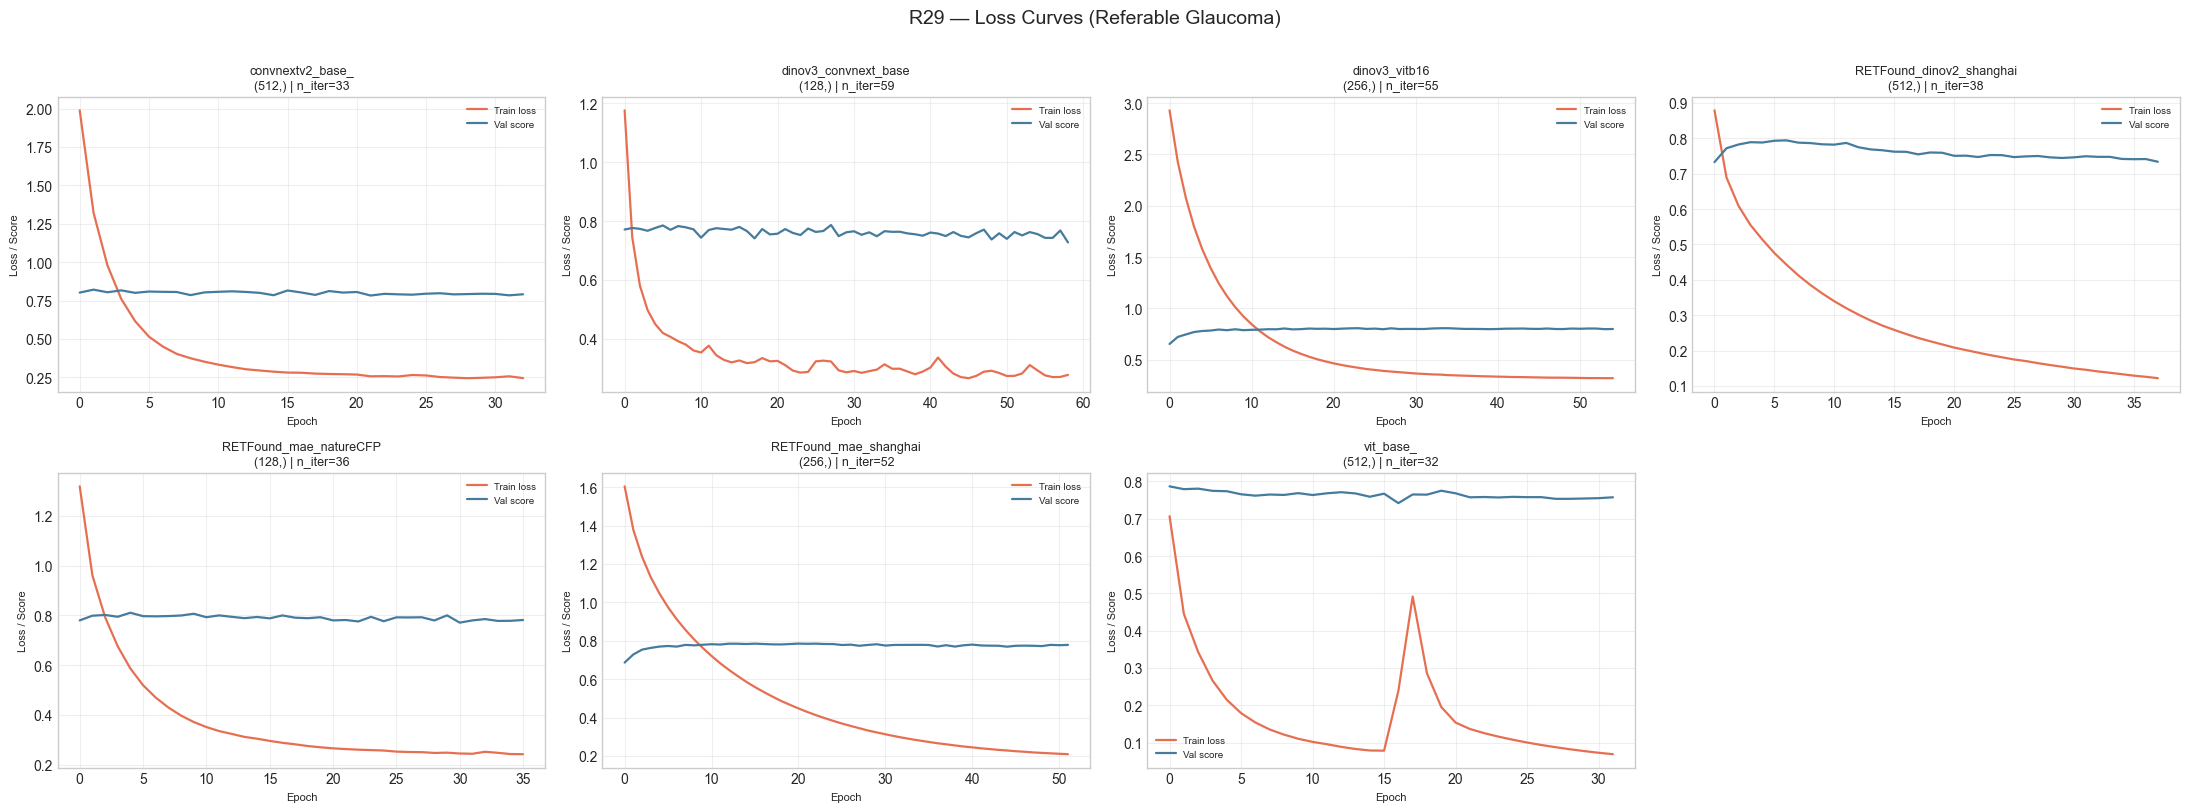

Loss curves saved.


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 7 — Loss Curves (self-contained) — R29 Referable Glaucoma
# ═══════════════════════════════════════════════════════════════════════

import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.exceptions import ConvergenceWarning
import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
from src.retina_embeddings_dataset import load_retina_embeddings_dataset
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')

# ─── Config ───────────────────────────────────────────────────────
TASK_SOURCE    = 'increased_cup_disc'
TASK           = 'referable_glaucoma'
RANDOM_SEED    = 42
PCA_COMPONENTS = 384
MI_THRESH      = 0.15
MI_MIN         = 128
MLP_MAX_ITER   = 400
MLP_PATIENCE   = 30
OD_P_MASK      = 0.50
OD_CORRUPT     = 0.10
OD_FW, OD_MW   = 0.50, 0.50

BASE    = Path.cwd()
FE_DIR  = BASE / 'artifacts' / 'brset_eda_fe'
EMB_DIR = BASE / 'data' / 'brset_embeddings'
LAB     = EMB_DIR / 'brset_labels' / 'labels_brset.csv'
R29_DIR = BASE / 'results' / 'brset_r29_referable_glaucoma' / 'r29_per_encoder'

METADATA_COLS = {'age': 'numeric', 'sex': 'passthrough', 'diabetes': 'binary_yn',
                 'exam_eye': 'binary', 'camera': 'camera'}

# ─── Helpers (inline) ─────────────────────────────────────────────
def _short(p): 
    s = Path(p).stem
    for x in ['Embeddings_brset_','Embeddings_']: s = s.replace(x,'')
    return s

def _bin_od(s): return (pd.to_numeric(s, errors='coerce') == 2).astype(np.float32).to_numpy()
def _mask_od(s, pm, rng, pc=0.0):
    od = _bin_od(s)
    miss = rng.random(len(od)) < pm if 0 < pm < 1 else (np.ones(len(od),bool) if pm>=1 else np.zeros(len(od),bool))
    od_m = od.copy(); od_m[miss]=0.0
    if pc>0:
        c=(~miss)&(rng.random(len(od))<pc); od_m[c]=1-od_m[c]
    return od_m.reshape(-1,1), miss.astype(np.float32).reshape(-1,1)

def _apply_w(X, ow, mw):
    if X.shape[1]>=2:
        if ow!=1: X[:,-2]*=ow
        if mw!=1: X[:,-1]*=mw
    return X

def _enc_meta(df, mc, fs=None):
    if fs is None: fs={}
    parts=[]
    for c,t in mc.items():
        if c not in df.columns: continue
        v=df[c].copy()
        if t=='numeric':
            v=pd.to_numeric(v,errors='coerce')
            if 'med_'+c not in fs: fs['med_'+c]=float(v.median())
            v=v.fillna(fs['med_'+c])
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1,1))
        elif t=='binary':
            v=pd.to_numeric(v,errors='coerce').fillna(1); v=(v-1).clip(0,1)
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1,1))
        elif t=='passthrough':
            v=pd.to_numeric(v,errors='coerce').fillna(0)
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1,1))
        elif t=='binary_yn':
            v=v.astype(str).str.lower().map({'yes':1.0,'no':0.0}).fillna(0.0)
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1,1))
        elif t=='camera':
            v=v.astype(str).map({'Canon CR':0.0,'NIKON NF5050':1.0}).fillna(0.0)
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1,1))
    return (np.hstack(parts),fs) if parts else (np.zeros((len(df),0),dtype=np.float32),fs)

def _make_w(y,w):
    y=np.asarray(y); sw=np.where(y==1,float(w),1.0).astype(np.float32)
    m=sw.mean(); return sw/m if m>0 else sw

# ─── Load data ────────────────────────────────────────────────────
fe_df = pd.read_csv(FE_DIR/'features_engineered_image_level.csv')
fe_df['patient_id'] = fe_df['patient_id'].astype(str)
sp = pd.read_csv(FE_DIR/'splits_patient.csv'); sp['patient_id']=sp['patient_id'].astype(str)
tr_p = set(sp[sp['split']=='train']['patient_id'])

lab = pd.read_csv(LAB); lab['patient_id']=lab['patient_id'].astype(str)
lab = lab.rename(columns={'patient_age':'age','patient_sex':'sex'})
pgc = lab.groupby('patient_id')[TASK_SOURCE].sum().rename('gc').reset_index()
pgc[TASK] = (pgc['gc']>=2).astype(int)
lab = lab.merge(pgc[['patient_id',TASK]], on='patient_id', how='left')
lab[TASK] = lab[TASK].fillna(0).astype(int)

emb_files = sorted(EMB_DIR.glob('Embeddings_*.csv'))

# ─── Encoder directories ──────────────────────────────────────────
enc_dirs = sorted([d for d in R29_DIR.iterdir() if d.is_dir() and (d/'hyperparameters.json').exists()])
print(f'Found {len(enc_dirs)} encoder checkpoints')

ncols = min(4, len(enc_dirs))
nrows = (len(enc_dirs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows), squeeze=False)

for idx, edir in enumerate(enc_dirs):
    hp = json.loads((edir/'hyperparameters.json').read_text())
    sn = hp['embedding']
    arch = eval(hp['architecture'])
    alpha = hp['alpha']; lr = hp['lr']; bs = hp['batch_size']; pw = hp['pos_weight']

    # find embedding file
    efp = None
    for ef in emb_files:
        if _short(ef) == sn: efp = ef; break
    if efp is None:
        print(f'  SKIP {sn}: embedding file not found'); continue

    ds = load_retina_embeddings_dataset(dataset='brset', embeddings_csv_path=efp, labels_csv_path=LAB)
    df = ds.df.copy(); df['patient_id']=df['patient_id'].astype(str)
    rl = lab[['image_id',TASK]].drop_duplicates(subset='image_id')
    if 'image_name' in df.columns and 'image_id' not in df.columns:
        df['image_id']=df['image_name'].str.replace(r'\.(jpg|png|jpeg)$','',regex=True)
    df = df.merge(rl, on='image_id', how='left'); df[TASK]=df[TASK].fillna(0).astype(int)
    bt = df[df['patient_id'].isin(tr_p)].dropna(subset=[TASK]).copy()

    X = bt[ds.feature_cols].to_numpy(dtype=np.float32)
    y = bt[TASK].to_numpy(dtype=int)

    nc = min(PCA_COMPONENTS, X.shape[1], X.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    Xp = pca.fit_transform(X)

    mi = mutual_info_classif(Xp, y, discrete_features=False, n_neighbors=5, random_state=RANDOM_SEED)
    th = np.percentile(mi, MI_THRESH*100)
    mask = mi >= th
    if mask.sum() < MI_MIN:
        tk = np.argsort(mi)[-MI_MIN:]; mask = np.zeros(len(mi),bool); mask[tk]=True
    Xs = Xp[:, mask]

    Xm, _ = _enc_meta(bt, METADATA_COLS)
    rng = np.random.default_rng(RANDOM_SEED)
    od, miss = _mask_od(bt['optic_disc'], OD_P_MASK, rng, OD_CORRUPT)
    Xf = np.hstack([Xs, Xm, od, miss])
    sc = StandardScaler(); Xf = sc.fit_transform(Xf)
    Xf = _apply_w(Xf, OD_FW, OD_MW)

    mlp = MLPClassifier(
        hidden_layer_sizes=arch, alpha=alpha, learning_rate='adaptive',
        learning_rate_init=lr, batch_size=bs, max_iter=MLP_MAX_ITER,
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=MLP_PATIENCE, random_state=RANDOM_SEED,
    )
    sw = _make_w(y, pw)
    mlp.fit(Xf, y, sample_weight=sw)

    ax = axes[idx//ncols][idx%ncols]
    tr_loss = mlp.loss_curve_
    va_loss = mlp.validation_scores_ if hasattr(mlp,'validation_scores_') and mlp.validation_scores_ else None
    ax.plot(tr_loss, label='Train loss', lw=1.6, color='#E76F51')
    if va_loss is not None:
        ax.plot(va_loss, label='Val score', lw=1.6, color='#457B9D')
    ax.set_title(f'{sn}\n{arch} | n_iter={mlp.n_iter_}', fontsize=9)
    ax.set_xlabel('Epoch', fontsize=8); ax.set_ylabel('Loss / Score', fontsize=8)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

# hide empty axes
for i in range(len(enc_dirs), nrows*ncols):
    axes[i//ncols][i%ncols].set_visible(False)

fig.suptitle('R29 — Loss Curves (Referable Glaucoma)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(R29_DIR.parent / 'r29_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved.')

---
## R29 vs R28 Comparison

Both experiments use identical pipeline and split — only the label differs:
- **R28:** Any glaucoma (increased_cup_disc in any image) → 19.7 %
- **R29:** Referable glaucoma (bilateral involvement) → 13.8 %

Loaded R28 baseline: 7 embeddings

R29 (Referable Glaucoma) vs R28 (Any Glaucoma)
model                embedding    cv_f1   val_f1    f1_P0   f1_P25  f1_P100  auc_P25
  R29            dinov3_vitb16 0.538132 0.748428 0.762712 0.721382 0.523457 0.950291
  R29         convnextv2_base_ 0.540066 0.777778 0.739300 0.698413 0.513636 0.951364
  R29     dinov3_convnext_base 0.493115 0.731844 0.718310 0.687161 0.525896 0.947150
  R29                vit_base_ 0.491495 0.749296 0.702703 0.661844 0.491620 0.937919
  R29    RETFound_mae_shanghai 0.497855 0.777778 0.685950 0.642398 0.424691 0.934782
  R29 RETFound_dinov2_shanghai 0.503449 0.729097 0.691207 0.642241 0.478261 0.929306
  R29   RETFound_mae_natureCFP 0.501928 0.707775 0.694444 0.633803 0.474820 0.922158
  R28     dinov3_convnext_base 0.620586 0.856566 0.870732 0.825822 0.606715 0.956253
  R28 RETFound_dinov2_shanghai 0.645074 0.844156 0.883375 0.825157 0.566197 0.959683
  R28    RETFound_mae_shanghai 0.610733 0.862745 0.890566 0.820513 0

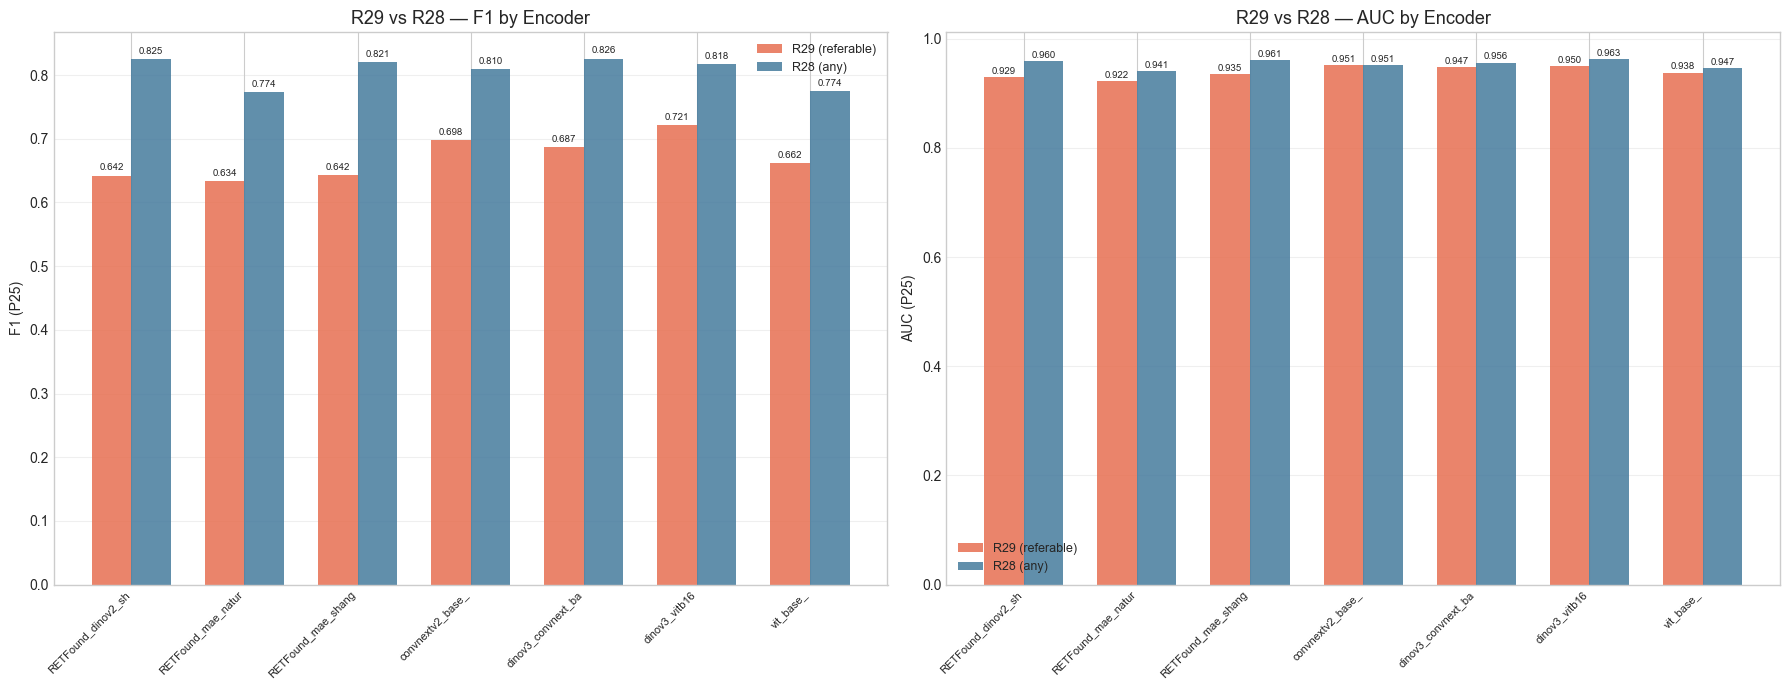


-- Per-Encoder Delta (R29 minus R28) --
  dinov3_vitb16                   dF1=-0.0965   dAUC=-0.0130
  convnextv2_base_                dF1=-0.1115   dAUC=-0.0001
  dinov3_convnext_base            dF1=-0.1387   dAUC=-0.0091
  vit_base_                       dF1=-0.1125   dAUC=-0.0089
  RETFound_mae_shanghai           dF1=-0.1781   dAUC=-0.0264
  RETFound_dinov2_shanghai        dF1=-0.1829   dAUC=-0.0304
  RETFound_mae_natureCFP          dF1=-0.1400   dAUC=-0.0189

Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r29_referable_glaucoma


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 9 — R29 vs R28 Comparison & Visualization
# ═══════════════════════════════════════════════════════════════════════

# ─── Load R28 baseline ────────────────────────────────────────────
has_r28 = R28_SUMMARY.exists()
if has_r28:
    r28_df = pd.read_csv(R28_SUMMARY)
    print(f'Loaded R28 baseline: {len(r28_df)} embeddings')
else:
    r28_df = pd.DataFrame()
    print('R28 baseline not found — comparison will be R29-only')

# ─── Build comparison table ───────────────────────────────────────
rows = []

for _, r in r29_df.iterrows():
    rows.append({
        'model': 'R29', 'embedding': r['embedding'],
        'f1_P25': r['f1_P25'], 'auc_P25': r['auc_P25'],
        'bal_acc_P25': r['bal_acc_P25'],
        'prec_P25': r['prec_P25'], 'rec_P25': r['rec_P25'],
        'f1_P0': r['f1_P0'], 'f1_P100': r['f1_P100'],
        'cv_f1': r['cv_f1'], 'val_f1': r['val_f1'],
    })

if has_r28:
    for _, r in r28_df.iterrows():
        rows.append({
            'model': 'R28', 'embedding': r['embedding'],
            'f1_P25': r.get('f1_P25', 0), 'auc_P25': r.get('auc_P25', 0),
            'bal_acc_P25': r.get('bal_acc_P25', 0),
            'prec_P25': r.get('prec_P25', 0), 'rec_P25': r.get('rec_P25', 0),
            'f1_P0': r.get('f1_P0', 0), 'f1_P100': r.get('f1_P100', 0),
            'cv_f1': r.get('cv_f1', 0), 'val_f1': r.get('val_f1', 0),
        })

comp_df = pd.DataFrame(rows)
comp_df.to_csv(RESULTS_DIR / 'r29_vs_r28_comparison.csv', index=False)

print('\n' + '=' * 110)
print('R29 (Referable Glaucoma) vs R28 (Any Glaucoma)')
print('=' * 110)
print(comp_df[['model','embedding','cv_f1','val_f1','f1_P0','f1_P25','f1_P100','auc_P25']].to_string(index=False))

# ─── Visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: F1 grouped bar (R29 vs R28 per encoder)
ax = axes[0]
if has_r28:
    encoders = sorted(set(r29_df['embedding']))
    x = np.arange(len(encoders))
    w = 0.35
    r29_f1 = [r29_df[r29_df['embedding']==e]['f1_P25'].values[0] if e in r29_df['embedding'].values else 0 for e in encoders]
    r28_f1 = [r28_df[r28_df['embedding']==e]['f1_P25'].values[0] if e in r28_df['embedding'].values else 0 for e in encoders]

    bars1 = ax.bar(x - w/2, r29_f1, w, label='R29 (referable)', color='#E76F51', alpha=0.85)
    bars2 = ax.bar(x + w/2, r28_f1, w, label='R28 (any)', color='#457B9D', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([e[:18] for e in encoders], rotation=45, ha='right', fontsize=8)
    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
else:
    x = np.arange(len(r29_df))
    ax.bar(x, r29_df['f1_P25'], color='#E76F51', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(r29_df['embedding'], rotation=45, ha='right', fontsize=8)

ax.set_ylabel('F1 (P25)')
ax.set_title('R29 vs R28 — F1 by Encoder', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Right: AUC comparison
ax2 = axes[1]
if has_r28:
    r29_auc = [r29_df[r29_df['embedding']==e]['auc_P25'].values[0] if e in r29_df['embedding'].values else 0 for e in encoders]
    r28_auc = [r28_df[r28_df['embedding']==e]['auc_P25'].values[0] if e in r28_df['embedding'].values else 0 for e in encoders]

    bars1 = ax2.bar(x - w/2, r29_auc, w, label='R29 (referable)', color='#E76F51', alpha=0.85)
    bars2 = ax2.bar(x + w/2, r28_auc, w, label='R28 (any)', color='#457B9D', alpha=0.85)

    ax2.set_xticks(x)
    ax2.set_xticklabels([e[:18] for e in encoders], rotation=45, ha='right', fontsize=8)
    for bars in [bars1, bars2]:
        for bar in bars:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
else:
    ax2.bar(x, r29_df['auc_P25'], color='#E76F51', alpha=0.85)

ax2.set_ylabel('AUC (P25)')
ax2.set_title('R29 vs R28 — AUC by Encoder', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'r29_vs_r28_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

# ─── Delta table ──────────────────────────────────────────────────
if has_r28:
    print('\n-- Per-Encoder Delta (R29 minus R28) --')
    for _, r29 in r29_df.iterrows():
        emb = r29['embedding']
        m28 = r28_df[r28_df['embedding'] == emb]
        if not m28.empty:
            df1 = r29['f1_P25'] - m28['f1_P25'].values[0]
            da  = r29['auc_P25'] - m28['auc_P25'].values[0]
            print(f'  {emb:<30}  dF1={df1:+.4f}   dAUC={da:+.4f}')

print(f'\nSaved: {RESULTS_DIR}')

---
## Interpretation Notes

**What to look for:**

1. **R29 vs R28:** Does referable glaucoma detection perform similarly to any-glaucoma?
   Lower prevalence (13.8% vs 19.7%) makes the task harder — some F1 drop is expected.
2. **AUC comparison:** If AUC holds up while F1 drops, the model still discriminates well
   but threshold calibration is harder due to imbalance.
3. **Encoder ranking:** Does the relative ranking of encoders change? If DINOv3-CN still
   leads, the pretraining advantage is task-agnostic.
4. **Clinical value:** A referable-glaucoma model has higher clinical utility — it answers
   "who needs a specialist?" rather than just "who has any structural change?"

**Key caveats:**
- Both experiments use the **same patient split** and **same pipeline** — only the binary
  label differs. This makes the comparison fair and controlled.
- Unilateral suspects are now in the **negative class** — these are the hardest negatives
  and may cause more false positives.

---
## §13 — Validation Suite (R29)

Same 5-test suite as R28, adapted for R29:
1. Bootstrap confidence intervals
2. Calibration reliability diagram
3. Subgroup fairness (sex / camera / diabetes)
4. Inter-encoder agreement (Cohen's Kappa)
5. Prediction error analysis (hard cases)

Loaded predictions for 7 encoders

TEST 1 — Bootstrap 95% Confidence Intervals
  convnextv2_base_               F1=0.698 [0.652,0.743]  AUC=0.951 [0.940,0.962]
  dinov3_convnext_base           F1=0.687 [0.642,0.732]  AUC=0.947 [0.932,0.960]
  dinov3_vitb16                  F1=0.721 [0.676,0.767]  AUC=0.950 [0.938,0.962]
  RETFound_dinov2_shanghai       F1=0.642 [0.591,0.691]  AUC=0.929 [0.914,0.943]
  RETFound_mae_natureCFP         F1=0.634 [0.587,0.680]  AUC=0.922 [0.905,0.938]
  RETFound_mae_shanghai          F1=0.642 [0.590,0.692]  AUC=0.935 [0.921,0.948]
  vit_base_                      F1=0.662 [0.616,0.706]  AUC=0.938 [0.923,0.951]


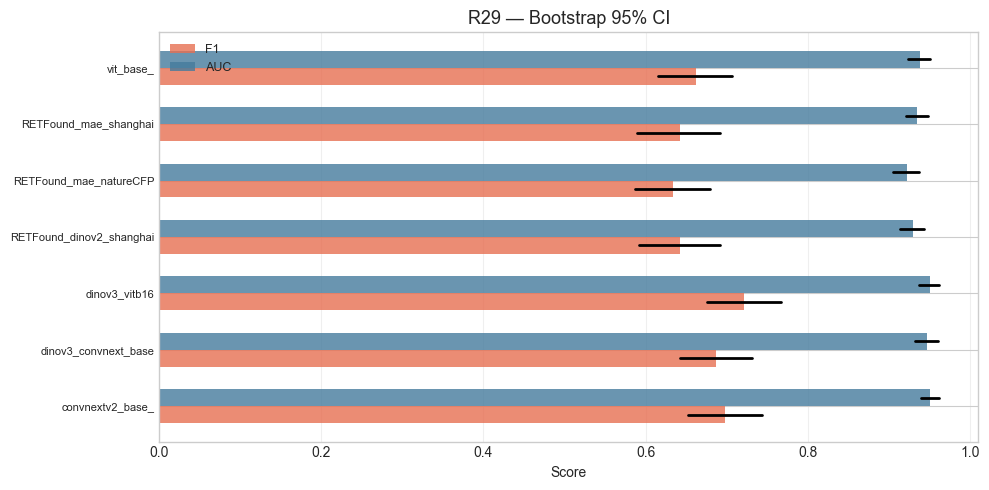


TEST 2 — Calibration Reliability Diagram
  convnextv2_base_               Brier=0.1192
  dinov3_convnext_base           Brier=0.0732
  dinov3_vitb16                  Brier=0.0712
  RETFound_dinov2_shanghai       Brier=0.0851
  RETFound_mae_natureCFP         Brier=0.0826
  RETFound_mae_shanghai          Brier=0.1084
  vit_base_                      Brier=0.0772


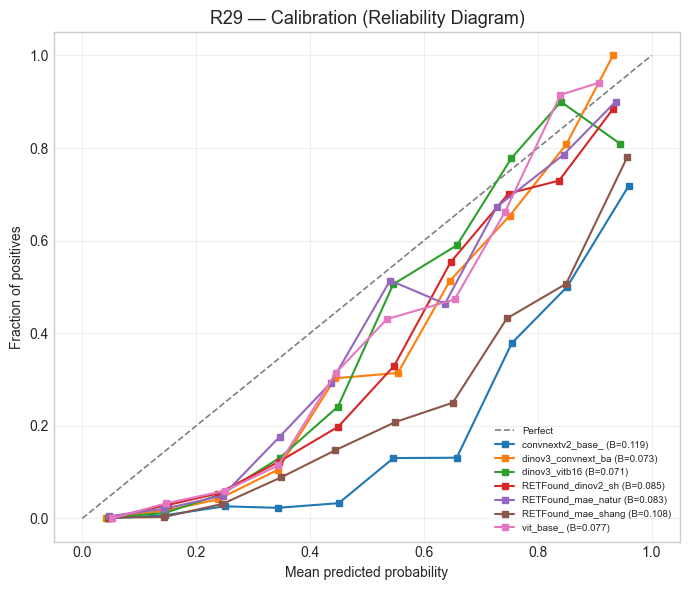


TEST 3 — Subgroup Fairness Analysis
  convnextv2_base_          sex        gap=0.028  {'1': 0.714975845410628, '2': 0.6868686868686869}
  convnextv2_base_          camera     gap=0.057  {'Canon CR': 0.7078384798099763, 'NIKON NF5050': 0.6506024096385542}
  convnextv2_base_          diabetes   gap=0.069  {'no': 0.7086247086247086, 'yes': 0.64}
  dinov3_convnext_base      sex        gap=0.030  {'1': 0.7048458149779736, '2': 0.6748466257668712}
  dinov3_convnext_base      camera     gap=0.000  {'Canon CR': 0.687089715536105, 'NIKON NF5050': 0.6875}
  dinov3_convnext_base      diabetes   gap=0.141  {'no': 0.7096774193548387, 'yes': 0.5681818181818182}
  dinov3_vitb16             sex        gap=0.054  {'1': 0.6885245901639344, '2': 0.7428571428571429}
  dinov3_vitb16             camera     gap=0.017  {'Canon CR': 0.7244094488188977, 'NIKON NF5050': 0.7073170731707317}
  dinov3_vitb16             diabetes   gap=0.076  {'no': 0.7333333333333333, 'yes': 0.6575342465753424}
  RETFound_dinov2_s

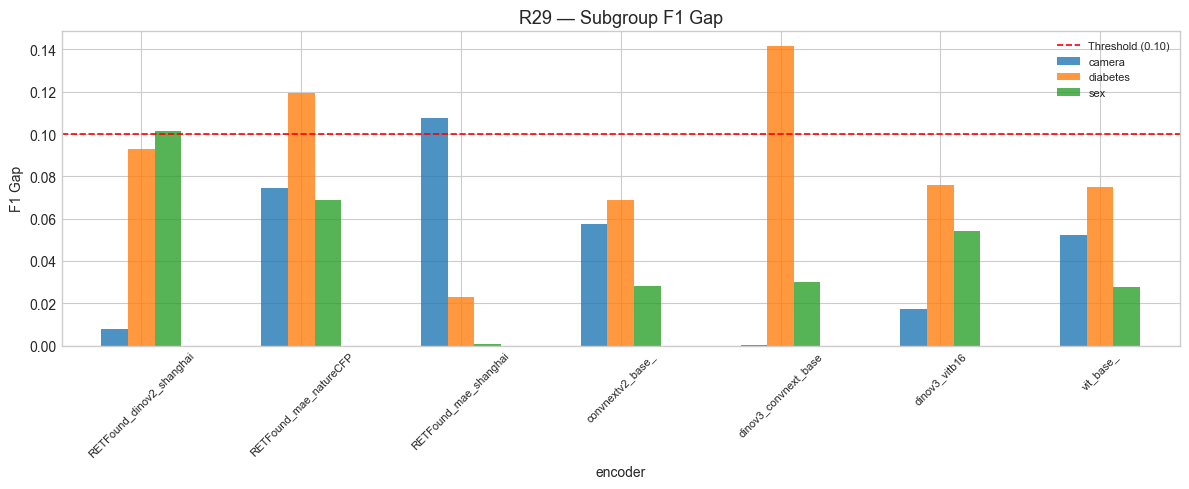


TEST 4 — Inter-Encoder Agreement
  Mean pairwise Kappa: 0.642
  Min: 0.552  Max: 0.731
  Unanimous agreement: 76.1%


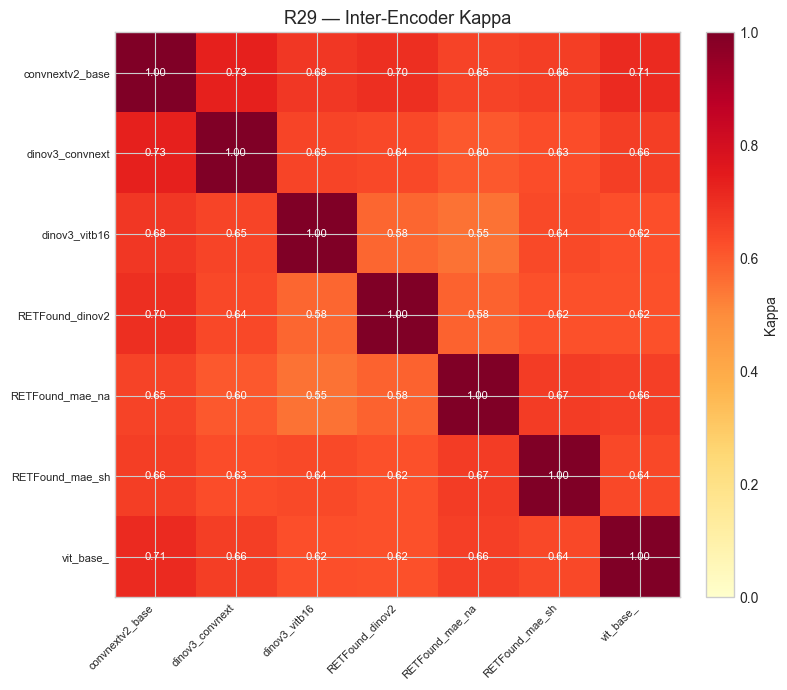


TEST 5 — Prediction Error Analysis (Hard Cases)
  convnextv2_base_               FP=99  FN=53
  dinov3_convnext_base           FP=134  FN=39
  dinov3_vitb16                  FP=67  FN=62
  RETFound_dinov2_shanghai       FP=86  FN=80
  RETFound_mae_natureCFP         FP=159  FN=49
  RETFound_mae_shanghai          FP=88  FN=79
  vit_base_                      FP=141  FN=46

  Hard FN patients (missed by ≥3 encoders): 67


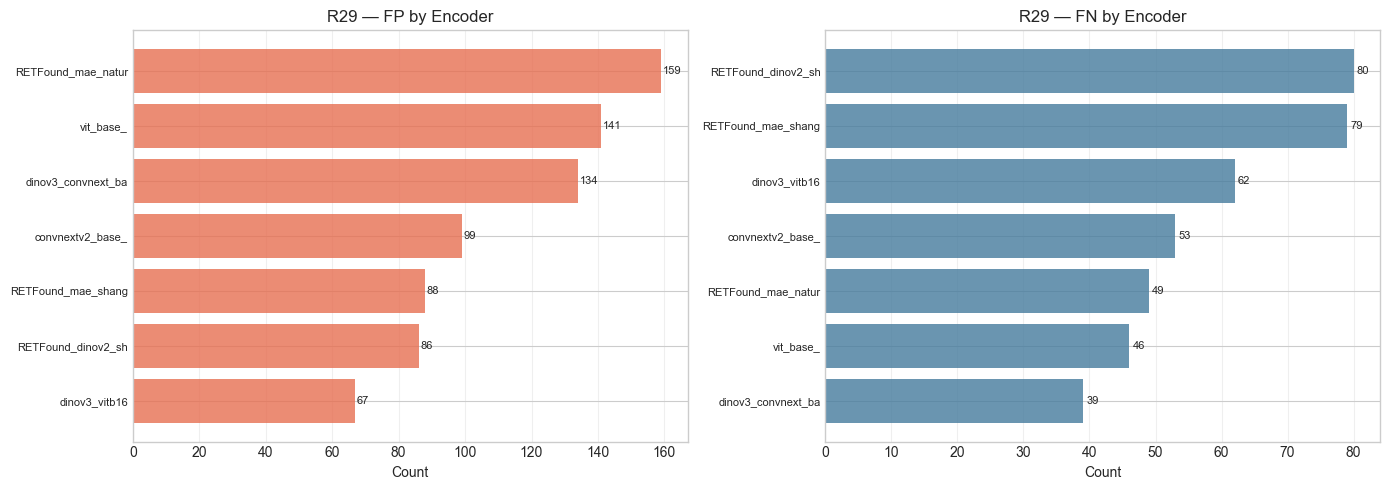


R29 VALIDATION SUITE — SUMMARY
  ⚠ T1: Bootstrap CI          WATCH  max CI width=0.102
  ✓ T2: Calibration           PASS   max Brier=0.119
  ✓ T3: Subgroup Fairness     PASS   worst gap=0.141
  ✓ T4: Inter-Encoder         PASS   unanimous=76.1%
  ⚠ T5: Error Analysis        WATCH  hard FN=67

  Result: 3 PASS / 2 WATCH
  Saved to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r29_referable_glaucoma\r29_per_encoder\validation_suite


In [1]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 11 — Validation Suite (R29 Referable Glaucoma)
# ═══════════════════════════════════════════════════════════════════════

import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

BASE    = Path.cwd()
R29_DIR = BASE / 'results' / 'brset_r29_referable_glaucoma' / 'r29_per_encoder'
LAB     = BASE / 'data' / 'brset_embeddings' / 'brset_labels' / 'labels_brset.csv'
VS_DIR  = R29_DIR / 'validation_suite'
VS_DIR.mkdir(exist_ok=True)

enc_dirs = sorted([d for d in R29_DIR.iterdir() if d.is_dir() and d.name != 'validation_suite'])

# ─── Load all predictions ─────────────────────────────────────────
preds = {}
for ed in enc_dirs:
    pp = ed / 'patient_predictions_P25.csv'
    if pp.exists():
        df = pd.read_csv(pp)
        df['patient_id'] = df['patient_id'].astype(str)          # ← normalise type
        hp = json.loads((ed/'hyperparameters.json').read_text())
        preds[hp['embedding']] = df

print(f'Loaded predictions for {len(preds)} encoders')

# Load labels for subgroup analysis
lab_raw = pd.read_csv(LAB)
lab_raw['patient_id'] = lab_raw['patient_id'].astype(str)
lab_raw = lab_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

# Patient-level metadata (first image per patient)
pat_meta = lab_raw.groupby('patient_id').first()[['age','sex','diabetes','camera']].reset_index()

summary = []

# ═══════════════════════════════════════════════════════════════════
# TEST 1: Bootstrap Confidence Intervals
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 1 — Bootstrap 95% Confidence Intervals')
print('='*80)

B = 2000
ci_rows = []
for enc, df in preds.items():
    yt = df['y_true'].values
    yp = df['y_proba'].values
    yh = df['y_pred'].values
    n = len(yt)
    rng = np.random.default_rng(42)
    f1s, aucs = [], []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(yt[idx])) < 2: continue
        f1s.append(f1_score(yt[idx], yh[idx], zero_division=0))
        aucs.append(roc_auc_score(yt[idx], yp[idx]))
    f1_lo, f1_hi = np.percentile(f1s, [2.5, 97.5])
    auc_lo, auc_hi = np.percentile(aucs, [2.5, 97.5])
    ci_rows.append({'encoder': enc,
                    'f1_point': f1_score(yt, yh, zero_division=0),
                    'f1_lo': f1_lo, 'f1_hi': f1_hi, 'f1_width': f1_hi-f1_lo,
                    'auc_point': roc_auc_score(yt, yp),
                    'auc_lo': auc_lo, 'auc_hi': auc_hi, 'auc_width': auc_hi-auc_lo})
    print(f'  {enc:<30} F1={f1_score(yt,yh,zero_division=0):.3f} [{f1_lo:.3f},{f1_hi:.3f}]  '
          f'AUC={roc_auc_score(yt,yp):.3f} [{auc_lo:.3f},{auc_hi:.3f}]')

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(VS_DIR / 'test1_bootstrap_ci.csv', index=False)

# CI plot
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(ci_df))
ax.barh(y_pos - 0.15, ci_df['f1_point'], 0.3, color='#E76F51', alpha=0.8, label='F1')
ax.barh(y_pos + 0.15, ci_df['auc_point'], 0.3, color='#457B9D', alpha=0.8, label='AUC')
for i, r in ci_df.iterrows():
    ax.plot([r['f1_lo'], r['f1_hi']], [i-0.15, i-0.15], 'k-', lw=2)
    ax.plot([r['auc_lo'], r['auc_hi']], [i+0.15, i+0.15], 'k-', lw=2)
ax.set_yticks(y_pos); ax.set_yticklabels(ci_df['encoder'], fontsize=8)
ax.set_xlabel('Score'); ax.set_title('R29 — Bootstrap 95% CI', fontsize=13)
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(VS_DIR / 'test1_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

max_width = ci_df['f1_width'].max()
t1_pass = max_width < 0.10
summary.append(('T1: Bootstrap CI', 'PASS' if t1_pass else 'WATCH', f'max CI width={max_width:.3f}'))

# ═══════════════════════════════════════════════════════════════════
# TEST 2: Calibration Reliability Diagram
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 2 — Calibration Reliability Diagram')
print('='*80)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1], [0,1], '--', color='gray', lw=1.2, label='Perfect')
brier_scores = []
for enc, df in preds.items():
    yt = df['y_true'].values; yp = df['y_proba'].values
    frac_pos, mean_pred = calibration_curve(yt, yp, n_bins=10, strategy='uniform')
    bs = brier_score_loss(yt, yp)
    brier_scores.append(bs)
    ax.plot(mean_pred, frac_pos, 's-', lw=1.5, markersize=5, label=f'{enc[:18]} (B={bs:.3f})')
    print(f'  {enc:<30} Brier={bs:.4f}')

ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('R29 — Calibration (Reliability Diagram)', fontsize=13)
ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(VS_DIR / 'test2_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

max_brier = max(brier_scores)
t2_pass = max_brier < 0.25
summary.append(('T2: Calibration', 'PASS' if t2_pass else 'WATCH', f'max Brier={max_brier:.3f}'))

# ═══════════════════════════════════════════════════════════════════
# TEST 3: Subgroup Fairness
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 3 — Subgroup Fairness Analysis')
print('='*80)

fair_rows = []
worst_gap = 0.0
for enc, df in preds.items():
    df2 = df.merge(pat_meta, on='patient_id', how='left')
    for attr in ['sex', 'camera', 'diabetes']:
        if attr not in df2.columns or df2[attr].nunique() < 2:
            continue
        groups = df2.groupby(attr)
        g_f1 = {}
        for gname, gdf in groups:
            if len(gdf) < 10 or gdf['y_true'].nunique() < 2: continue
            g_f1[str(gname)] = f1_score(gdf['y_true'], gdf['y_pred'], zero_division=0)
        if len(g_f1) >= 2:
            vals = list(g_f1.values())
            gap = max(vals) - min(vals)
            worst_gap = max(worst_gap, gap)
            fair_rows.append({'encoder': enc, 'attribute': attr,
                              'groups': str(g_f1), 'gap': gap})
            print(f'  {enc[:25]:<25} {attr:<10} gap={gap:.3f}  {g_f1}')

fair_df = pd.DataFrame(fair_rows)
fair_df.to_csv(VS_DIR / 'test3_subgroup_fairness.csv', index=False)

# Fairness bar plot
if not fair_df.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    fair_piv = fair_df.pivot(index='encoder', columns='attribute', values='gap').fillna(0)
    fair_piv.plot(kind='bar', ax=ax, alpha=0.8)
    ax.axhline(0.10, ls='--', color='red', lw=1.2, label='Threshold (0.10)')
    ax.set_ylabel('F1 Gap'); ax.set_title('R29 — Subgroup F1 Gap', fontsize=13)
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=45, labelsize=8)
    plt.tight_layout()
    fig.savefig(VS_DIR / 'test3_subgroup_fairness.png', dpi=150, bbox_inches='tight')
    plt.show()

t3_pass = worst_gap < 0.15
summary.append(('T3: Subgroup Fairness', 'PASS' if t3_pass else 'WATCH', f'worst gap={worst_gap:.3f}'))

# ═══════════════════════════════════════════════════════════════════
# TEST 4: Inter-Encoder Agreement (Cohen's Kappa)
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 4 — Inter-Encoder Agreement')
print('='*80)

from sklearn.metrics import cohen_kappa_score

enc_names = list(preds.keys())
n_enc = len(enc_names)
kappa_mat = np.zeros((n_enc, n_enc))

for i in range(n_enc):
    for j in range(n_enc):
        if i == j:
            kappa_mat[i, j] = 1.0
            continue
        df_i = preds[enc_names[i]].set_index('patient_id')
        df_j = preds[enc_names[j]].set_index('patient_id')
        common = df_i.index.intersection(df_j.index)
        if len(common) > 0:
            kappa_mat[i, j] = cohen_kappa_score(
                df_i.loc[common, 'y_pred'],
                df_j.loc[common, 'y_pred'],
            )

kappa_df = pd.DataFrame(kappa_mat, index=enc_names, columns=enc_names)
kappa_df.to_csv(VS_DIR / 'test4_inter_encoder_kappa.csv')

off_diag = kappa_mat[np.triu_indices(n_enc, k=1)]
mean_kappa = off_diag.mean()
print(f'  Mean pairwise Kappa: {mean_kappa:.3f}')
print(f'  Min: {off_diag.min():.3f}  Max: {off_diag.max():.3f}')

# Check unanimous agreement rate
if len(preds) >= 2:
    first_enc = list(preds.values())[0]
    common_pids = set(first_enc['patient_id'])
    for df in preds.values():
        common_pids &= set(df['patient_id'])
    all_preds_df = pd.DataFrame({'patient_id': list(common_pids)})
    for enc, df in preds.items():
        all_preds_df = all_preds_df.merge(
            df[['patient_id','y_pred']].rename(columns={'y_pred': enc}),
            on='patient_id', how='left')
    pred_cols = [c for c in all_preds_df.columns if c != 'patient_id']
    unanimous = (all_preds_df[pred_cols].nunique(axis=1) == 1).mean()
    print(f'  Unanimous agreement: {unanimous:.1%}')

# Kappa heatmap
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(kappa_mat, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n_enc)); ax.set_yticks(range(n_enc))
ax.set_xticklabels([e[:15] for e in enc_names], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([e[:15] for e in enc_names], fontsize=8)
for (i,j), v in np.ndenumerate(kappa_mat):
    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
            color='white' if v > 0.5 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Kappa')
ax.set_title('R29 — Inter-Encoder Kappa', fontsize=13)
plt.tight_layout()
fig.savefig(VS_DIR / 'test4_inter_encoder_kappa.png', dpi=150, bbox_inches='tight')
plt.show()

t4_pass = unanimous >= 0.70 if 'unanimous' in dir() else mean_kappa > 0.4
summary.append(('T4: Inter-Encoder', 'PASS' if t4_pass else 'WATCH',
                 f'unanimous={unanimous:.1%}' if 'unanimous' in dir() else f'mean_kappa={mean_kappa:.3f}'))

# ═══════════════════════════════════════════════════════════════════
# TEST 5: Prediction Error Analysis
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 5 — Prediction Error Analysis (Hard Cases)')
print('='*80)

hard_cases = []
for enc, df in preds.items():
    fp = df[(df['y_true'] == 0) & (df['y_pred'] == 1)].copy()
    fn = df[(df['y_true'] == 1) & (df['y_pred'] == 0)].copy()
    fp['error_type'] = 'FP'
    fn['error_type'] = 'FN'
    fp['encoder'] = enc
    fn['encoder'] = enc
    hard_cases.append(pd.concat([fp, fn]))
    print(f'  {enc:<30} FP={len(fp)}  FN={len(fn)}')

hc_df = pd.concat(hard_cases, ignore_index=True)

# Count how often each patient is misclassified across encoders
fn_counts = hc_df[hc_df['error_type']=='FN'].groupby('patient_id').size().sort_values(ascending=False)
hard_fn = fn_counts[fn_counts >= len(preds) // 2]  # misclassified by majority
print(f'\n  Hard FN patients (missed by ≥{len(preds)//2} encoders): {len(hard_fn)}')

hc_df.to_csv(VS_DIR / 'test5_hard_cases.csv', index=False)

# Error analysis plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, etype in enumerate(['FP', 'FN']):
    ax = axes[i]
    sub = hc_df[hc_df['error_type'] == etype]
    enc_counts = sub.groupby('encoder').size().sort_values(ascending=True)
    ax.barh(range(len(enc_counts)), enc_counts.values, color='#E76F51' if etype=='FP' else '#457B9D', alpha=0.8)
    ax.set_yticks(range(len(enc_counts)))
    ax.set_yticklabels([e[:18] for e in enc_counts.index], fontsize=8)
    ax.set_xlabel('Count'); ax.set_title(f'R29 — {etype} by Encoder', fontsize=12)
    for j, v in enumerate(enc_counts.values):
        ax.text(v + 0.5, j, str(v), va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(VS_DIR / 'test5_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

t5_pass = len(hard_fn) < 50
summary.append(('T5: Error Analysis', 'PASS' if t5_pass else 'WATCH', f'hard FN={len(hard_fn)}'))

# ═══════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('R29 VALIDATION SUITE — SUMMARY')
print('='*80)
for name, status, detail in summary:
    icon = '✓' if status == 'PASS' else '⚠'
    print(f'  {icon} {name:<25} {status:<6} {detail}')

n_pass = sum(1 for _, s, _ in summary if s == 'PASS')
n_watch = sum(1 for _, s, _ in summary if s == 'WATCH')
print(f'\n  Result: {n_pass} PASS / {n_watch} WATCH')
print(f'  Saved to: {VS_DIR}')